In [313]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [314]:
# Import libraries
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn import preprocessing
from sklearn import linear_model
import statsmodels.api as sm
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor


# 1- Business and data understanding and preparation

In [315]:
# Read data
qualitywine = pd.read_csv("/content/drive/MyDrive/IS470_data/winequality-red.csv")
qualitywine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [316]:
# Examine variable type
qualitywine.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [317]:
qualitywine[['alcohol', 'sulphates','volatile acidity']].corr()

,alcohol,sulphates,volatile acidity
alcohol,1.000000,0.093595,-0.202288
sulphates,0.093595,1.000000,-0.260987
volatile acidity,-0.202288,-0.260987,1.000000


Text(0.5, 1.0, 'Histogram of alcohol content in wine')

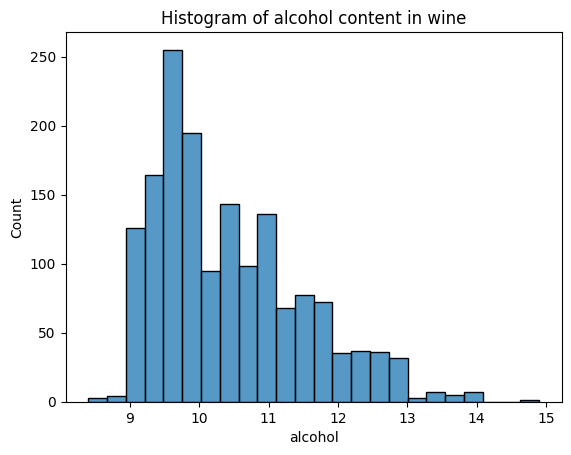

In [318]:
# Data exploration: some examples
# Histogram of alcohol
snsplot = sns.histplot(x='alcohol', data=qualitywine)
snsplot.set_title("Histogram of alcohol content in wine")

Define Main objective: The main objective in this assignment or task is to determine if any attributes impact the quality of wine. I will find the quality of wine based on several factors and find any kind of corralation between these factors.

Identify who might benefit from this analysis: Any reader of this information can benefit from this analysis. This means that a reader for fun can see what can determine the quality of wine. Going more in depth sommeliers are the ones that greatly will benefit form this information as they can enrich their knowledge about wine far much more than what they already know. Lastly, businesses can use this inforamtion to make better more well informed decisions about choosing the wine that best fits their bussiness goals.

Frame the problem as a numeric predicition task: Since the score is a number, we are not classifying the wine into categories (like 'good' or 'bad'); instead, we are attempting to predict the specific numerical value (e.g., 6.5, 7.2), which is the defining characteristic of a regression problem.

Improving or changing factors: Changing factors can impact product quality as we will be able to determine if such combination of facotrs produce a lower quality wine or other factors classified together can make a better quality wine.

Outline the success criteria: By tuning our models I will be able to achieve a realiable predictive model. This will mean that the models will be accurate to interprete the numeric predictions


# 2- Simple Linear Regression

In [319]:
# Prepare data for Linear Regression models (using original numerical 'quality')
# Re-read data to ensure we have the original numerical 'quality' column
qualitywine_regression = pd.read_csv("/content/drive/MyDrive/IS470_data/winequality-red.csv")

# Define all numerical columns as predictors, excluding 'quality'
predictors_regression = qualitywine_regression.drop('quality', axis=1)
target_regression = qualitywine_regression['quality']

# Split the data into training and testing sets for regression
predictors_train_reg, predictors_test_reg, target_train_reg, target_test_reg = train_test_split(
    predictors_regression, target_regression, test_size=0.3, random_state=0
)

print(predictors_train_reg.shape, predictors_test_reg.shape, target_train_reg.shape, target_test_reg.shape)


(1119, 11) (480, 11) (1119,) (480,)


In [320]:
# Build a simple linear regression model with only bmi as predictor
model1 = linear_model.LinearRegression()
model1.fit(predictors_train_reg[['sulphates', 'alcohol', 'volatile acidity']], target_train_reg)

LinearRegression()

In [321]:
# Show model summary
X2 = sm.add_constant(predictors_train_reg[['sulphates', 'alcohol', 'volatile acidity']])
y = target_train_reg
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.346
Model:                            OLS   Adj. R-squared:                  0.344
Method:                 Least Squares   F-statistic:                     196.8
Date:                Sat, 22 Nov 2025   Prob (F-statistic):          2.02e-102
Time:                        12:24:25   Log-Likelihood:                -1132.2
No. Observations:                1119   AIC:                             2272.
Df Residuals:                    1115   BIC:                             2292.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.8428      0.235  

In [322]:
# Make predictions on testing data
prediction_on_test = model1.predict(predictors_test_reg[['sulphates', 'alcohol', 'volatile acidity']])

In [323]:
# Examine the evaluation results on testing data: MAE and RMSE
MAE = mean_absolute_error(target_test_reg, prediction_on_test)
RMSE = mean_squared_error(target_test_reg, prediction_on_test)
print("MAE:", MAE)
print("RMSE:", RMSE**0.5)

MAE: 0.49989475419835716
RMSE: 0.6431641181181005


# 3- Multiple Linear Regression

In [324]:
# Build a multiple linear regression model with all predictors
model2 = linear_model.LinearRegression()
model2.fit(predictors_train_reg, target_train_reg)

LinearRegression()

In [325]:
# Show model summary
import statsmodels.api as sm
X2 = sm.add_constant(predictors_train_reg)
y = target_train_reg
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.371
Model:                            OLS   Adj. R-squared:                  0.365
Method:                 Least Squares   F-statistic:                     59.35
Date:                Sat, 22 Nov 2025   Prob (F-statistic):          1.86e-103
Time:                        12:24:25   Log-Likelihood:                -1110.6
No. Observations:                1119   AIC:                             2245.
Df Residuals:                    1107   BIC:                             2305.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   21.0111 

In [326]:
# Make predictions on testing data
prediction_on_test = model2.predict(predictors_test_reg)

In [327]:
# Examine the evaluation results on testing data: MAE and RMSE
MAE = mean_absolute_error(target_test_reg, prediction_on_test)
RMSE = mean_squared_error(target_test_reg, prediction_on_test)
print("MAE:", MAE)
print("RMSE:", RMSE**0.5)

MAE: 0.48712621645927945
RMSE: 0.6330721652189464


Interpretation: For the R-squared value the rsult on the training set is 0.371 which means this is good and no overfitting occurred when executed.
The OLS regression analysis identifies Alcohol, Sulphates, and Volatile Acidity as the three most statistically significant predictors of wine quality, all having P> values of 0.000. Both Alcohol (coefficient: 0.2675 and Sulphates (coefficient: 0.8542 have a positive relationship with quality; an increase in either attribute, which often signals better body or preservation, leads to a higher predicted quality score. Conversely, Volatile Acidity (coefficient:
-1.2139 has a strong negative relationship; as a marker for spoilage (vinegar), every unit increase causes a substantial decrease in the predicted wine quality score. This is all absed on the coefficients that we can see and how they directly change as the variables.

MAE is at 0.48 and RMSE is at 0.63 which is good considering that we do not want these values high as it would mean are model failed. Now we would want these values to be more separated in terms in value to obtain the highest performance but we are still able to see valuable information. We canaestbalish that our mdoel can identify these errors based on the MAE and RMSE. From simple linear regression to multiple linear regression we do not see much of a change however mulitple linear regression performs slightly better.

# 4- Regression Trees

In [328]:
# Selecting 4 attributes that help determine quality of a wine
predictors = qualitywine[['volatile acidity', 'chlorides', 'sulphates', 'alcohol']]
target = qualitywine['quality']

predictors_train, predictors_test, target_train, target_test = train_test_split(predictors, target, test_size=0.3, random_state=0)
print(predictors_train.shape, predictors_test.shape, target_train.shape, target_test.shape)

(1119, 4) (480, 4) (1119,) (480,)


In [329]:
# Build a regression tree model with max_depth=3
model5 = DecisionTreeRegressor(random_state=0, max_depth=3)
model5.fit(predictors_train, target_train)

DecisionTreeRegressor(max_depth=3, random_state=0)

[Text(0.5, 0.875, 'alcohol <= 10.525\nsquared_error = 0.677\nsamples = 1119\nvalue = 5.651'),
 Text(0.25, 0.625, 'sulphates <= 0.555\nsquared_error = 0.434\nsamples = 690\nvalue = 5.384'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'chlorides <= 0.169\nsquared_error = 0.281\nsamples = 230\nvalue = 5.122'),
 Text(0.0625, 0.125, 'squared_error = 0.258\nsamples = 228\nvalue = 5.136'),
 Text(0.1875, 0.125, 'squared_error = 0.25\nsamples = 2\nvalue = 3.5'),
 Text(0.375, 0.375, 'volatile acidity <= 0.335\nsquared_error = 0.458\nsamples = 460\nvalue = 5.515'),
 Text(0.3125, 0.125, 'squared_error = 0.508\nsamples = 51\nvalue = 6.039'),
 Text(0.4375, 0.125, 'squared_error = 0.414\nsamples = 409\nvalue = 5.45'),
 Text(0.75, 0.625, 'sulphates <= 0.615\nsquared_error = 0.77\nsamples = 429\nvalue = 6.082'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'volatile acidity <= 1.0\nsquared_error = 0.747\nsamples = 160\nvalue = 5.625'),
 Text(0.5625, 0.125, 'squared_error = 0.569\nsamples = 

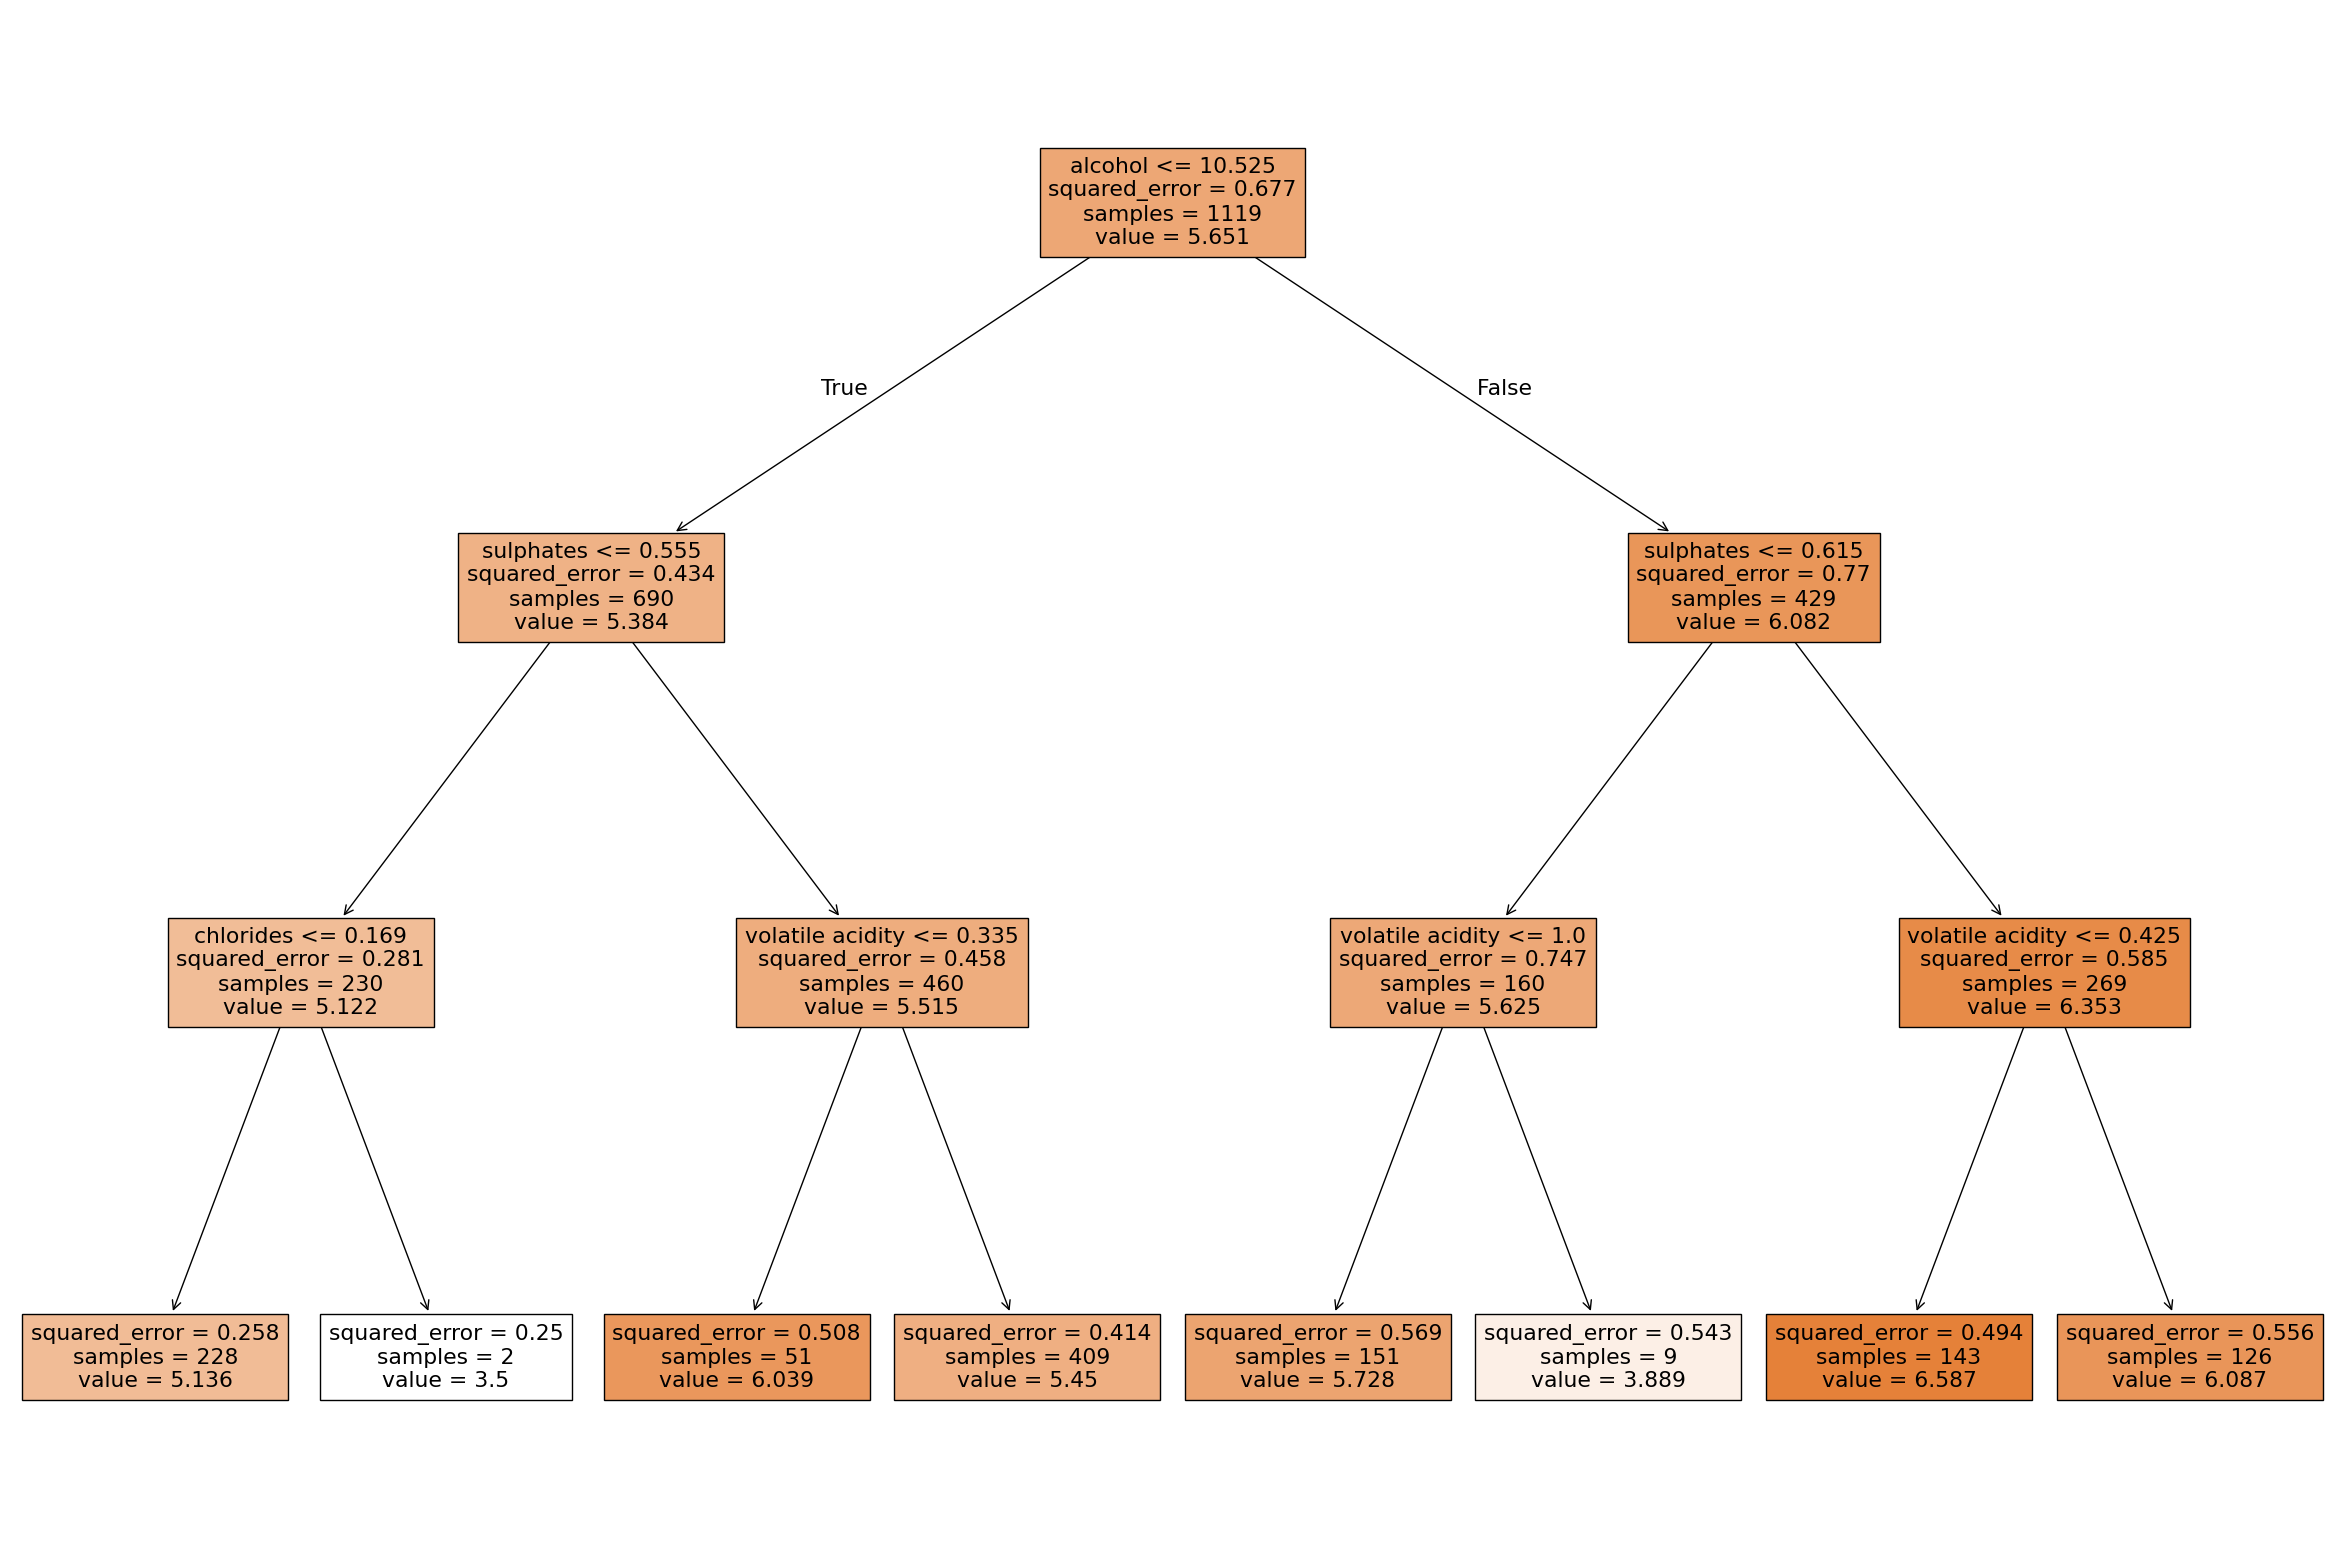

In [330]:
from matplotlib import pyplot as plt
from sklearn import tree
fig = plt.figure(figsize=(30,20))
tree.plot_tree(model5,
               feature_names=list(predictors_train.columns),
               filled=True)

In [331]:
# Make predictions on testing data
prediction_on_test = model5.predict(predictors_test)

In [332]:
# Examine the evaluation results on testing data: MAE and RMSE
MAE = mean_absolute_error(target_test, prediction_on_test)
RMSE = mean_squared_error(target_test, prediction_on_test)
print("MAE:", MAE)
print("RMSE:", RMSE**0.5)

MAE: 0.542425292632813
RMSE: 0.6876191960234269


comparing this to the other modles it does not perform better in terms of MAE and RMSE. Although we can argue it still performs good enough but compared to linear regression it performs slightly worse.

# 5- SVR

In [333]:
# Build a SVM model with default setting (C = 1.0)
model_SVM1 = SVR(C=25)
model_SVM1.fit(predictors_train_reg, target_train_reg)

SVR(C=25)

In [334]:
# Make predictions on testing data
prediction_on_test = model_SVM1.predict(predictors_test_reg)

In [335]:
# Examine the evaluation results on testing data: MAE and RMSE
MAE = mean_absolute_error(target_test_reg, prediction_on_test)
MSE = mean_squared_error(target_test_reg, prediction_on_test)
RMSE = MSE**0.5
print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 0.48530650023977656
RMSE: 0.6379212880587782


The performance on this model is good in respect to MAE being 0.48 however, for RMSE it did not perform well as regression tree model performed better in this area. This will be an interesting model to look at to see if it can be trained to be the best even if it takes a lot of time and effort because it seems to have potentail as MAE is at 0.48. I would also like to dive deeper into why it performed worse for RMSE making this model not the best than any of the previous ones.

# 6- Multi-layer Perceptron (MLP)

In [336]:
#Build MLP model contains two hidden layers: 16 hidden nodes for the first layer, and 8 hidden nodes for the second layer. Set random_state=1.
model_MLP1 = MLPRegressor(hidden_layer_sizes=(60,30), random_state=1)
model_MLP1.fit(predictors_train_reg, target_train_reg)

MLPRegressor(hidden_layer_sizes=(60, 30), random_state=1)

In [337]:
# Make predictions on testing data
prediction_on_test_insurance = model_MLP1.predict(predictors_test_reg)

In [338]:
# Examine the evaluation results on testing data: MAE and RMSE
MAE = mean_absolute_error(target_test_reg, prediction_on_test_insurance)
MSE = mean_squared_error(target_test_reg, prediction_on_test_insurance)
RMSE = MSE**0.5
print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 0.48693092346424977
RMSE: 0.6369633330187275


To better improve this model a series of alterations had to be made for the hidden layers. These alterations agve me the best output for MAE and RMSE which came very close to outperfomring my best model being the mulitple linear regression. In this model MAE performed slightly better than mulitple linear regression and this is in the slightest wihch is still impressive. However in the multiple linear regression model it was still able to outperform this MLP model in RMSE. Depending what my goals are or if I am looking for something specific that will depedn on which one of theses two models I can use to determine the goals.

# 7- Model Comparison

Regression Model Performance Comparison:
                        Model     MAE    RMSE
0    Simple Linear Regression  0.4999  0.6432
1  Multiple Linear Regression  0.4871  0.6331
2            Regression Trees  0.5424  0.6876
3                         SVR  0.4853  0.6379
4                         MLP  0.4869  0.6370


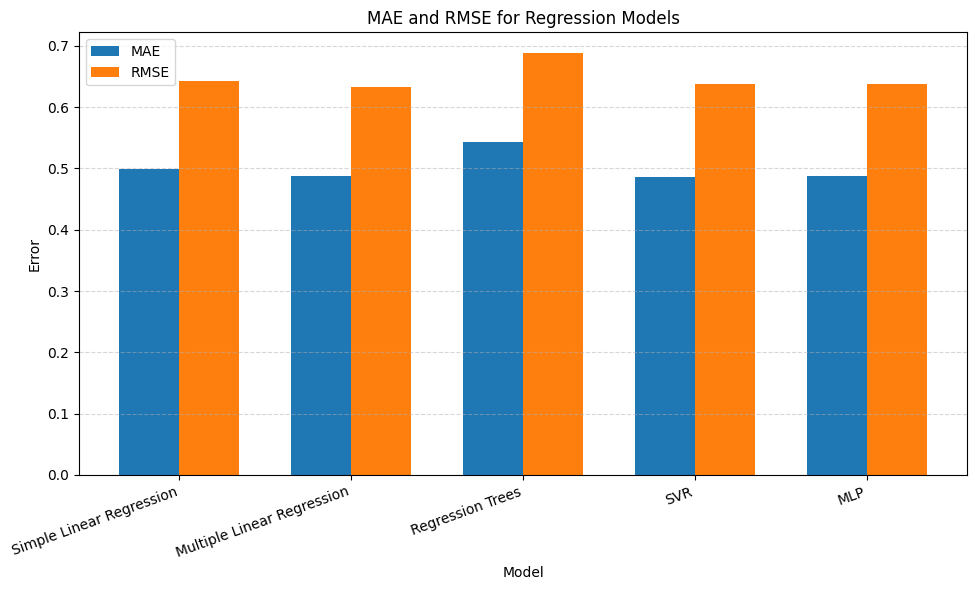

In [339]:
# Compile and compare MAE and RMSE values from all regression models

regression_results = {
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression', 'Regression Trees', 'SVR', 'MLP'],
    'MAE': [0.49989475419835716, 0.48712621645927945, 0.542425292632813, 0.48530650023977656, 0.48693092346424977],
    'RMSE': [0.6431641181181005, 0.6330721652189464, 0.6876191960234269, 0.6379212880587782, 0.6369633330187275]
}

results_df = pd.DataFrame(regression_results);
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Regression Model Performance Comparison:")
print(results_df.round(4))
x = np.arange(len(results_df['Model']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, results_df['MAE'], width, label='MAE')
ax.bar(x + width/2, results_df['RMSE'], width, label='RMSE')

ax.set_xlabel('Model')
ax.set_ylabel('Error')
ax.set_title('MAE and RMSE for Regression Models')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

1. Lowest MAE
SVR has the lowest Mean Absolute Error (0.4853), meaning on average it makes the smallest magnitude of mistakes when predicting wine quality.
2. Very Competitive RMSE
Its RMSE (0.6379) is also among the best.
Although Multiple Linear Regression has slightly lower RMSE (0.6331), its MAE is higher, meaning its average errors are worse.

More importantly if we had to choose if we wanted a better MAE or RMSE I strongly encourage that in this study we should focus on MAE as it is the mean of errors essebtially deminishing the value of RMSE. Although SVR has a higher RMSE meaning it makes more big mistakes it does not affect MAE as much as one would think which still outperforms the other models in the mean error category.

The SVR model has the lowest MAE, meaning its wine quality predictions are closest to the true values on average. This is important in the business point of view as it determines the value of the wine you posses. As a business you want your customers to enjoy your product and create the best experience possible. Using these models to obtain the true values and determining which wines produce the best quality can imporve your business by improving an existing product in an exisitng market.

# 8- Classification

In [340]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [341]:
# Read data
qualitywine = pd.read_csv("/content/drive/MyDrive/IS470_data/winequality-red.csv")

# Apply the quality conversion for classification (to 'No'/'Yes')
# Ensure mapping keys are strings to match the .astype(str) conversion
quality_mapping = {str(score): 'No' for score in range(6)} # Map qualities '0'-'5' to 'No'
quality_mapping.update({str(score): 'Yes' for score in range(6, 10)}) # Map qualities '6'-'9' to 'Yes'

# Ensure 'quality' column is treated as strings for mapping, then apply mapping
qualitywine.loc[:, 'quality'] = qualitywine['quality'].astype(str)
qualitywine.loc[:, 'quality'] = qualitywine['quality'].replace(quality_mapping)

qualitywine

/tmp/ipython-input-1158583593.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['5' '5' '5' ... '6' '5' '6']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  qualitywine.loc[:, 'quality'] = qualitywine['quality'].astype(str)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,No
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,No
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,No
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,Yes
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,No
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,No
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,Yes
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,Yes
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,No


In [342]:
# Partition the data for classification
from sklearn.preprocessing import MinMaxScaler

# Define predictors (X) and target (y)
# All columns except 'quality' are predictors
X = qualitywine.drop('quality', axis=1)
# The 'quality' column, now mapped to 'No'/'Yes', is the target
y = qualitywine['quality']

# Scale the numerical predictors using MinMaxScaler
scaler = MinMaxScaler()
predictors_normalized = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Split the data into training and testing sets
predictors_train, predictors_test, target_train, target_test = train_test_split(predictors_normalized, y, test_size=0.3, random_state=0)

print(predictors_train.shape, predictors_test.shape, target_train.shape, target_test.shape)

(1119, 11) (480, 11) (1119,) (480,)


In [343]:
# Build a SVM model with default setting (C = 1.0) (0.5 points)
model_svm1 = SVC()
model_svm1.fit(predictors_train, target_train)

SVC()

In [344]:
# Examine the porportion of target variable for training data set
print(target_train.value_counts(normalize=True))

quality
Yes    0.537087
No     0.462913
Name: proportion, dtype: float64


In [345]:
# Examine the porportion of target variable for testing data set
print(target_test.value_counts(normalize=True))

quality
Yes    0.529167
No     0.470833
Name: proportion, dtype: float64


In [346]:
# Build a SVM model with default setting (C = 1.0) (0.5 points)
model_svm1 = SVC()
model_svm1.fit(predictors_train, target_train)

SVC()

In [347]:
# Make predictions on testing data (0.5 points)
prediction_on_test_svm = model_svm1.predict(predictors_test)

In [348]:
# Examine the evaluation results on testing data: confusion_matrix (0.5 points)cm = confusion_matrix(target_test, prediction_on_test)
cm = confusion_matrix(target_test, prediction_on_test_svm)


In [349]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score (0.5 points)
print(classification_report(target_test, prediction_on_test_svm))

              precision    recall  f1-score   support

          No       0.73      0.72      0.72       226
         Yes       0.75      0.76      0.76       254

    accuracy                           0.74       480
   macro avg       0.74      0.74      0.74       480
weighted avg       0.74      0.74      0.74       480



In [350]:
# Examine the evaluation results on testing data: MAE and RMSE
# This cell is for regression evaluation and is not applicable for classification models.
# MAE = mean_absolute_error(target_test, prediction_on_test)
# RMSE = mean_squared_error(target_test, prediction_on_test)
# print("MAE:", MAE)
# print("RMSE:", RMSE**0.5)

In [351]:
#Build MLP model contains two hidden layers: 64 hidden nodes for the first layer, 16 hidden nodes for the second layer, and 8 hidden nodes for the third layer. Set random_state=1. (0.5 points)
hidden_layer_sizes_tuple = (64, 16, 8)
mlp_model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes_tuple, random_state=1)
mlp_model.fit(predictors_train, target_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(64, 16, 8), random_state=1)

In [352]:
# Make predictions on testing data (0.5 points)
prediction_on_test_mlp = mlp_model.predict(predictors_test)

In [353]:
# Examine the evaluation results on testing data: confusion_matrix (0.5 points)
cm = confusion_matrix(target_test, prediction_on_test_svm)

In [354]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score (0.5 points)
print(classification_report(target_test, prediction_on_test_mlp))

              precision    recall  f1-score   support

          No       0.73      0.68      0.70       226
         Yes       0.73      0.78      0.75       254

    accuracy                           0.73       480
   macro avg       0.73      0.73      0.73       480
weighted avg       0.73      0.73      0.73       480



I took a left turn when it came to classification as I wanted to prove how it can be used in an unorthodox way. I was able to separate the wines from quality ratings 0-5 and 6-9 and making a classification report. In reality this does not prove much as it cannot give a clear answer on what attributes make the best wine however it is plenty useful to narrow down the search. For example, the report with 'yes' means that the quality is from 6-9 so you know it will be quality wine and can safely choose from this. In a business standpoint you can choose from the higher end or lower end depending on your business needs or how you want your business to perform according to the quality wine being served. Now if you want lower quality wine then you can go on the other end but lets face it no business would want to serve cheap low quality wine. In this case we can rule out the low end wine and focus on the quality wine from the report. From here it becomes so much easier moving forward to linear regression or any other models but it is not only limited to that as the information can be taken at face value and still make good decisions from it.

The appraoch I like better and strongly believe serves a better purpose in the business world would be regresssion. This gives data in numbers that are easily read and easy to manipulate to have a menaingful impact in a business. As seen in my models it becomes extremly competitive on which model performs the best and for this reason accuracy becomes and ally and you have several models that can help you enhance whichever business.

In [361]:
!jupyter nbconvert "/content/drive/MyDrive/Colab Notebooks/Assignment3.ipynb" --to html

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Assignment3.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 952077 bytes to /content/drive/MyDrive/Colab Notebooks/Assignment3.html
